In [37]:
import numpy as np
import matplotlib.pyplot as plt
from qm import SimulationConfig
from qm.qua import *
import os
import xarray as xr
import json
from quam_libs.components import QuAM
from quam_libs.lib.save_utils import find_numbered_folder
import scipy.optimize


In [20]:
def load_dataset(serial_number, target_filename = "ds", parameters = None):
    """
    Loads a dataset from a file based on the serial number.
    
    Args:
        serial_number: The serial number to search for.
        base_folder: The base directory to search in.
    
    Returns:
        An xarray Dataset if found, None otherwise.
    """
    if not isinstance(serial_number, int):
        raise ValueError("serial_number must be an integer")
        
    base_folder = "/Users/mohammadkashani/Documents/Qolab/qolab-start/data/"
    for subfolder in os.listdir(base_folder):
        if os.path.isdir(os.path.join(base_folder, subfolder)):
            for subfolder_2 in os.listdir(os.path.join(base_folder, subfolder)):
                if '#'+str(serial_number) in os.path.basename(subfolder_2):
                    base_folder = os.path.join(base_folder, subfolder, subfolder_2)
                    break
    print(f"Searching in folder: {base_folder}")
        
    print(f"Loading data from folder: {base_folder}")
    # Look for .nc files in the subfolder
    nc_files = [f for f in os.listdir(base_folder) if f.endswith('.h5')]
    print(nc_files)
    # look for filename.h5
    is_present = target_filename in [file.split('.')[0] for file in nc_files]
    filename = [file for file in nc_files if target_filename == file.split('.')[0]][0] if is_present else None
    json_filename = "data.json"
    
    if nc_files:
        # Assuming there's only one .nc file per folder
        file_path = os.path.join(base_folder, filename)
        json_path = os.path.join(base_folder, json_filename)
        # Open the dataset
        print(f"Loading dataset from file: {file_path}")
        ds = xr.open_dataset(file_path)
        with open(json_path, 'r') as f:
            json_data = json.load(f)
        try:
            machine = QuAM.load(base_folder + "/quam_state/state.json")
        except Exception as e:
            print(f"Error loading machine: {e}")
            machine = None
        qubits = [machine.qubits[qname] for qname in ds.qubit.values]    
        if parameters is not None:
            for param_name, param_value in parameters:
                if param_name != "load_data_id":
                    if param_name in json_data["initial_parameters"]:
                        setattr(parameters, param_name, json_data["initial_parameters"][param_name])
            return ds, machine, json_data, qubits,parameters
        else:
            return ds, machine, json_data, qubits
    else:
        print(f"No .nc file found in folder: {base_folder}")
        return None


# Probelm #2

RB Fitting - fit the RB and extract the fidelity and discuss which qubit is better?

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-12/#81_10a_Single_Qubit_Randomized_Benchmarking_151746
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-12/#81_10a_Single_Qubit_Randomized_Benchmarking_151746
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-12/#81_10a_Single_Qubit_Randomized_Benchmarking_151746/ds.h5


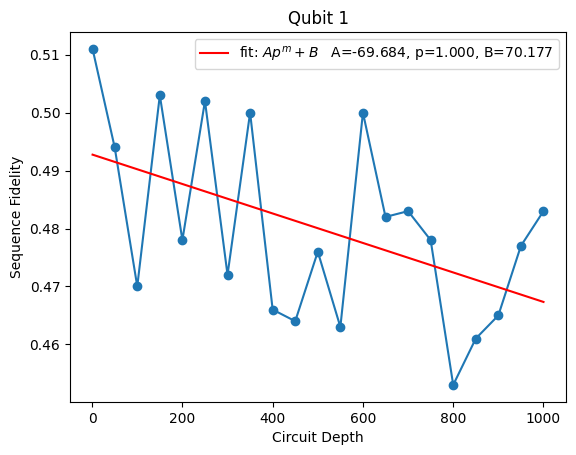

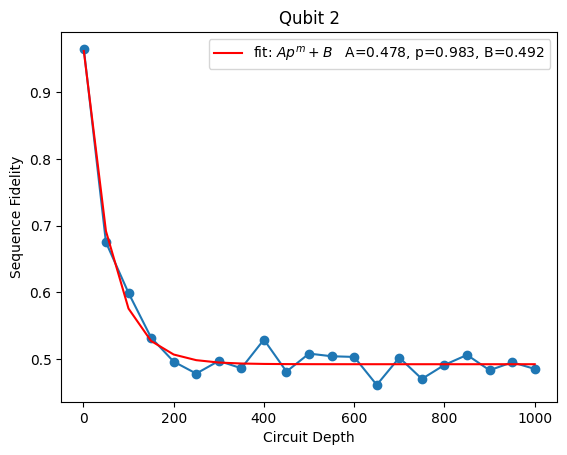

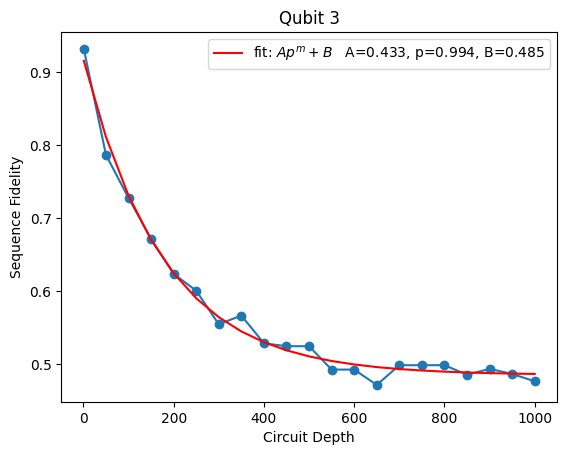

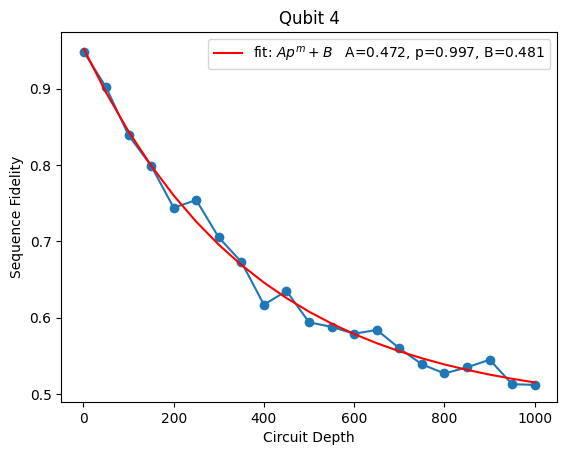

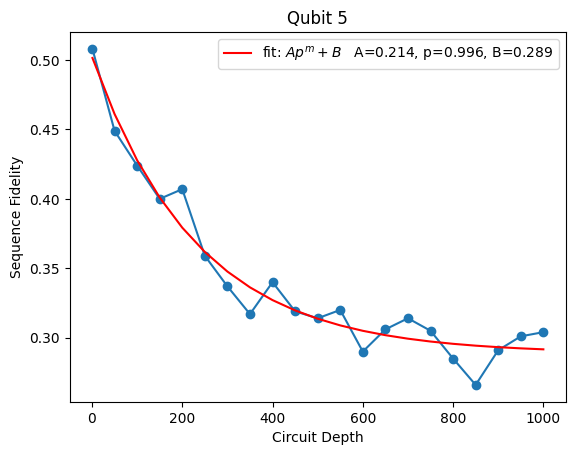

{'Qubit_1': {'A': -69.68406621291237,
             'B': 70.17683955143315,
             'p': 1.0000003651455185},
 'Qubit_2': {'A': 0.4780599921912272,
             'B': 0.4920508413161864,
             'p': 0.9826989603643316},
 'Qubit_3': {'A': 0.4325982048197728,
             'B': 0.48549893080928275,
             'p': 0.9943577497463442},
 'Qubit_4': {'A': 0.47177498086831243,
             'B': 0.48132365225744506,
             'p': 0.9973721927941339},
 'Qubit_5': {'A': 0.21366778973511727,
             'B': 0.28871607546064565,
             'p': 0.9957161759860713}}


In [51]:
import pprint

b = load_dataset(81)


def func(x, a, p, b):
    return a * np.power(p,x) + b


P = {}
for i in range(5):
    x = b[0]["depths"].values
    xdata = 1-np.mean(b[0]["state"].values[i],axis=0)
    popt, pcov = scipy.optimize.curve_fit(func, x,xdata)

    plt.plot(b[0]["depths"].values,xdata,"o-")
    plt.plot(b[0]["depths"].values, func(x, *popt), 'r-',
         label= r'fit: $A p^{m} + B$   A=%5.3f, p=%5.3f, B=%5.3f' % tuple(popt))
    
    plt.xlabel("Circuit Depth")
    plt.ylabel("Sequence Fidelity")
    plt.title(f"Qubit {i+1}")
    plt.legend()
    plt.show()
    P[f"Qubit_{i+1}"] = {'A': popt[0], 'p': popt[1], 'B': popt[2]}
pprint.pprint(P)


This is the resutls of fitting the curve to Qubits:

```bash
{
 'Qubit_1': {'A': -69.68406621291237,
             'B': 70.17683955143315,
             'p': 1.0000003651455185},


 'Qubit_2': {'A': 0.4780599921912272,
             'B': 0.4920508413161864,
             'p': 0.9826989603643316},

 'Qubit_3': {'A': 0.4325982048197728,
             'B': 0.48549893080928275,
             'p': 0.9943577497463442},

 'Qubit_4': {'A': 0.47177498086831243,
             'B': 0.48132365225744506,
             'p': 0.9973721927941339},
             
 'Qubit_5': {'A': 0.21366778973511727,
             'B': 0.28871607546064565,
             'p': 0.9957161759860713}}
}
```





## Problem #3
Extract the data from experiment 110 and compare the qubit.

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-13/#110_10a_Single_Qubit_Randomized_Benchmarking_043752
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-13/#110_10a_Single_Qubit_Randomized_Benchmarking_043752
['ds.h5']
Loading dataset from file: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-11-13/#110_10a_Single_Qubit_Randomized_Benchmarking_043752/ds.h5


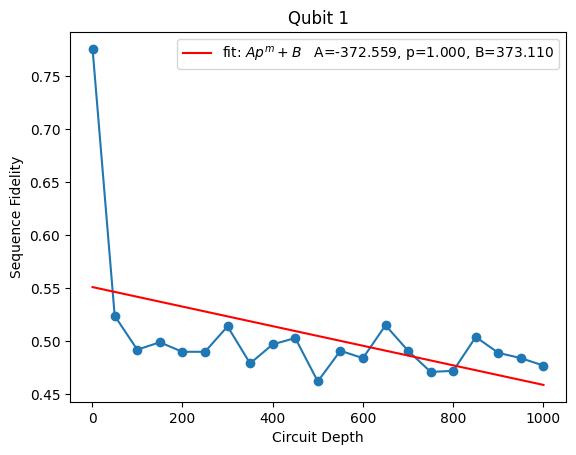

{'Qubit_1': {'A': -372.5589834631924,
             'B': 373.1101746490843,
             'p': 1.0000002481772274}}


In [54]:
b = load_dataset(110)


def func(x, a, p, b):
    return a * np.power(p,x) + b


P = {}
for i in range(1):
    x = b[0]["depths"].values
    xdata = 1-np.mean(b[0]["state"].values[i],axis=0)
    popt, pcov = scipy.optimize.curve_fit(func, x,xdata)

    plt.plot(b[0]["depths"].values,xdata,"o-")
    plt.plot(b[0]["depths"].values, func(x, *popt), 'r-',
         label= r'fit: $A p^{m} + B$   A=%5.3f, p=%5.3f, B=%5.3f' % tuple(popt))
    
    plt.xlabel("Circuit Depth")
    plt.ylabel("Sequence Fidelity")
    plt.title(f"Qubit {i+1}")
    plt.legend()
    plt.show()
    P[f"Qubit_{i+1}"] = {'A': popt[0], 'p': popt[1], 'B': popt[2]}
pprint.pprint(P)

## The only line changes is the amplitude of the x180 drag cosine amplitude. from .19 -> .08

<img src="img/HW3-state-json-difference.png" alt="alt text" style="width:700px;">

## Problem #4
In this exercise, you will actually run something
on the Qolab chip. Your token must be properly setup or this will not work. Please
submit your data directory along with the other parts.

a) First, compare the state.json file for dataset 110 (found in data/2025-11-
13/#110 10a Single Qubit Randomized Benchmarking 043752/quam state) to the
state.json in your qolab-start config/quam state folder. Note that config/quam -
state/state.json is what is used to actually run experiments. By editing the file
directly, change the single variable identified in problem 3 to the value from dataset 110. This should intentionally ‘detune’ the qubit. In the ‘Node Library’ tab, run node
10a Single Qubit Randomized Benchmarking for only qubit 4 (by entering ‘q4’ in
the qubits box and clicking ‘Run’). What is resulting error? Is this better or worse
than the average error seen in problem 2 and in problem 3? Dataset 110 may be
useful as reference

### a



## Problem #5
Within the data folder, I have included several datasets for almost all pre-loaded nodes, including ones we ran and discussed in class and ones that we have not. Pick one dataset that is not RB, Power Rabi, T1, or IQ blob(that is perhaps relevant to your final project). What does that node do, from a qubit tune-up perspective? Look at the data and make observations. Look at the source code for the experiment and make observations.


Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-13/#59_05_T1_160858
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-13/#59_05_T1_160858
['ds.h5']


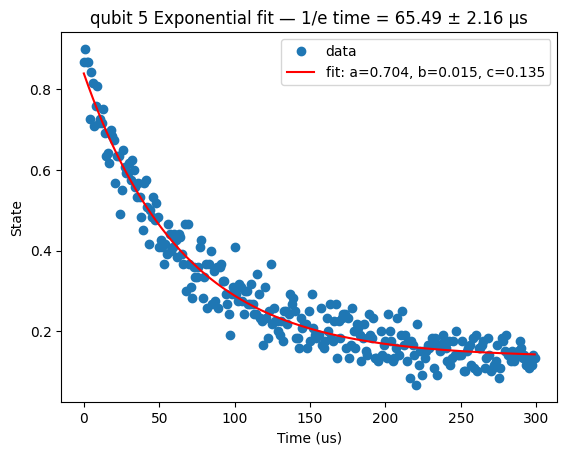

In [64]:
import scipy.optimize

d_58 = load_dataset(58)


def func(x, a, b, c):
    return a * np.exp(-b * x) + c

xdata = d_58[0]["idle_time"]


popt, pcov = scipy.optimize.curve_fit(func, d_58[0]["idle_time"],d_58[0]['state'].values[0])

plt.plot(d_58[0]["idle_time"],d_58[0]['state'].values[0],"o",label="data")
plt.plot(xdata, func(xdata, *popt), 'r-',
         label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt))

plt.xlabel("Time (us)")
plt.ylabel("State")
plt.legend()
# compute 1/e time and its uncertainty from fit parameter b and show in the title
b = popt[1]
db = np.sqrt(pcov[1, 1])
t1 = 1.0 / b if b != 0 else float("inf")
dt1 = db / b**2 if b != 0 else 0.0
plt.title(f"qubit 5 Exponential fit — 1/e time = {t1:.2f} ± {dt1:.2f} µs")

plt.show()

Searching in folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-14/#70_05_T1_091936
Loading data from folder: /Users/mohammadkashani/Documents/Qolab/qolab-start/data/2025-10-14/#70_05_T1_091936
['ds.h5']


/Users/mohammadkashani/Documents/Qolab/qolab-start/.venv/lib/python3.11/site-packages/xarray/computation/apply_ufunc.py:814: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)


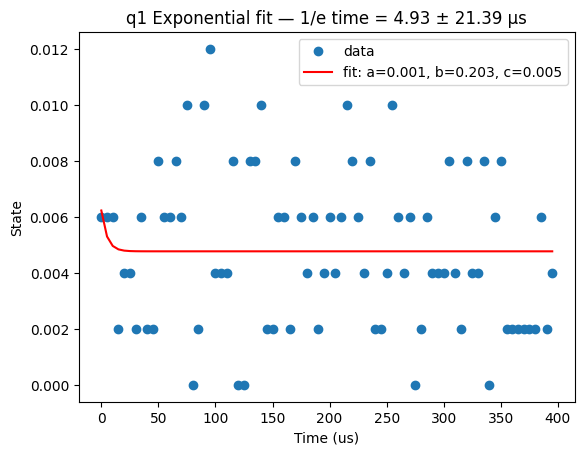

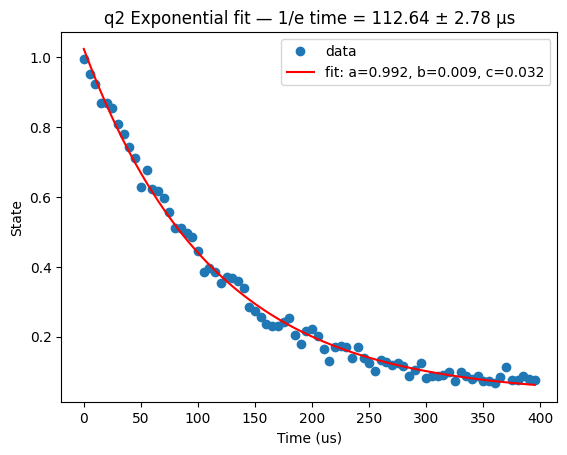

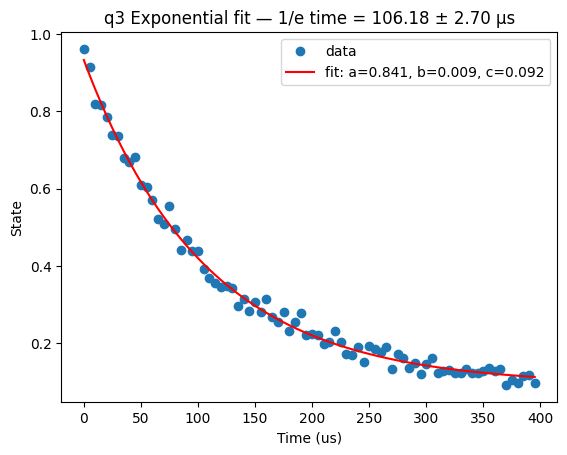

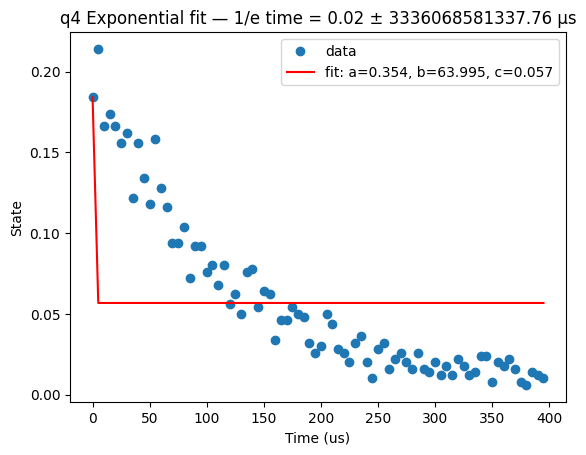

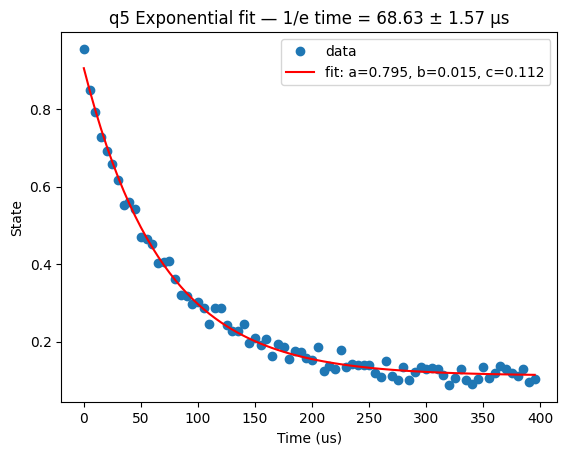

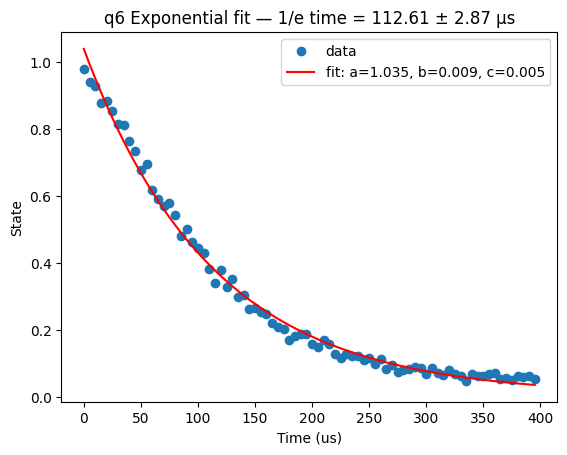

In [65]:

d_70 = load_dataset(70)
xdata = d_70[0]["idle_time"]

for i in range(0,6):

    popt, pcov = scipy.optimize.curve_fit(func, d_70[0]["idle_time"],d_70[0]['state'].values[i])

    plt.plot(d_70[0]["idle_time"],d_70[0]['state'].values[i],"o",label="data")
    plt.plot(xdata, func(xdata, *popt), 'r-',
            label='fit: a=%5.3f, b=%5.3f, c=%5.3f' % tuple(popt))

    plt.xlabel("Time (us)")
    plt.ylabel("State")
    plt.legend()
    # compute 1/e time and its uncertainty from fit parameter b and show in the title
    b = popt[1]
    db = np.sqrt(pcov[1, 1])
    t1 = 1.0 / b if b != 0 else float("inf")
    dt1 = db / b**2 if b != 0 else 0.0
    plt.title(f"q{i+1} Exponential fit — 1/e time = {t1:.2f} ± {dt1:.2f} µs")

    plt.show()


# Qubit comparison
based on the t1 time the the dataset 70 overall was better tuned. Moreover, in the dataset 70 the qubit 6 is performing better.

# Qeustion 4 

Between the experiments run on 2025/10/13
and 2025/10/14, there was a large change in performance. This can be attributed to
the tune-up of the qubits between 10-13 and 10-14. All of the attributes that go into
this are in the state.json file. Compare the
data/2025-10-13/#58 05 T1 160134/quam state/state.json and
data/2025-10-14/#70 05 T1 091936/quam state/state.json files. What are the
most significant changes between the two? How, in terms of Hamiltonians, resonators,
input/output theory, IQ Blobs, or any other concept we have learned, would that have
had an impact?


In [66]:
import os
os.system("diff ../data/2025-10-13/#58_05_T1_160134/quam_state/state.json ../data/2025-10-14/#70_05_T1_091936/quam_state/state.json ")

0

# Answer to question 4

I have used the git diff to find the differences. Since the json file is Organized by qubit the changes is also organized by qubit;

Changes (There are some changes with the q1. Since we know that q1 is not working properly I assume that with every different tuning there would a different optimized value and hence I am ignoring all the changes for the q1 qubit.

- The coeficient and the phase of the drag signals have slightly changed. The dragsignals are used to reduce the state leackage probablity of going from |1> to |2>
- In the 'xy' operation parameters there is a saturation value that has changes and I don't know what that is?
- In the 'z' operation parametese there is a independent_offset that has been changes which I assume it is the offset needed for synchronizing the moving frame with the rotating frame for the virtual Z gates.
- The resonators readout values have been changed 
  - "amplitude": 0.13462579588477366, (this is the amplitude of the RF prob signal that is send to measure the state of the qubit)
  - "threshold": 0.00016816928812431303, (this I assume is the threshold of the readout signal that indicates if you are in which state for the IQ blob)
  - "rus_exit_threshold": 9.786276098748899e-05, (no clue)
  - "integration_weights_angle": -10.691949911844818, (no clue)
- "intermediate_frequency": -249085112.0, (this indicates the frequency of the resonator)
- "time_of_flight": 416, (this indicated the time it takes for the RF signal to gets down to the qubit)
- 
- "freq_vs_flux_01_quad_term": -27135854341.73669, (I am not sure what this actually is but I know that the resonating frequncy of the qubit can be modified by the flux that is induced by the flux line)
- "phi0_current": 34.93260262518741, (this must be the current of the flux line)
- "phi0_voltage": 0.6986520525037482, (and this must be the voltage of the flux line that controls the resonance frequncy of the qubit)
- "chi": -600000.0, (have no clue)

whole file changes:
- Analog output control for the qubit 5 has been modified to add a delay
  - "delay": 250,
- And also the mw output has been modified (I don't know what that is)